# File for exploring relevant data and how to connect to it

For a first project, a sensible data stack would be:

- *Power data*: ENTSO-E via entsoe-py for Sweden
- *Historical weather*: SMHI Open Data API for station-based - observations near your area of interest, ERA5 via cdsapi for gridded reanalysis as a fallback or complement
- *Weather forecasts*: Open-Meteo Historical Forecast API — free, no registration, Python-friendly JSON, and specifically suited for ML training because it mirrors real forecast model output rather than reanalysis



Coordinates: 60.25247573852539°N 19.902908325195312°E
Elevation: 12.0 m asl
Timezone: b'Europe/Mariehamn'b'GMT+2'
Timezone difference to GMT+0: 7200s

Hourly data
                          date  temperature_2m
0   2025-07-01 00:00:00+00:00        9.806500
1   2025-07-01 01:00:00+00:00        8.856501
2   2025-07-01 02:00:00+00:00        7.956500
3   2025-07-01 03:00:00+00:00        7.456500
4   2025-07-01 04:00:00+00:00        7.106500
..                        ...             ...
739 2025-07-31 19:00:00+00:00       19.906500
740 2025-07-31 20:00:00+00:00       18.806499
741 2025-07-31 21:00:00+00:00       17.156500
742 2025-07-31 22:00:00+00:00       15.456500
743 2025-07-31 23:00:00+00:00       14.256500

[744 rows x 2 columns]


Text(0, 0.5, 'Temperature (°C)')

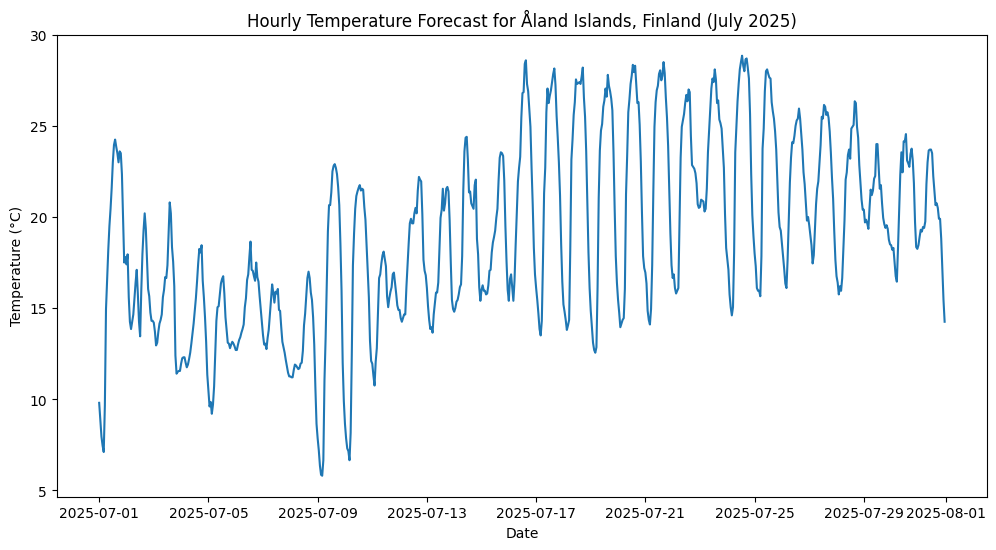

In [7]:
# For getting historical weather forecasts for Åland Islands, Finland
# Using the Open-Meteo API: https://open-meteo.com/en/docs
# Link to historical forecast API: https://open-meteo.com/en/docs/historical-forecast-api

# Step 0 — Install dependencies:
# pip install openmeteo-requests requests-cache retry-requests pandas numpy
# pip install matplotlib # (Optional)


# Step 1 — Set up the client with caching:
import openmeteo_requests
import requests_cache
import pandas as pd
from retry_requests import retry
import matplotlib.pyplot as plt # For plotting the data (optional)

# Cache responses locally to avoid re-downloading the same data
cache_session = requests_cache.CachedSession(".cache", expire_after=-1)  # -1 = cache forever
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)


# Step 2 — uery the Historical Forecast API:
# The endpoint for historical forecast data is `/v1/forecast` with a `start_date` and `end_date` in the past.

# Coordinates for Stockholm — replace with your target location
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"

params = {
    "latitude": 60.25,              # Åland Islands latitude (central point)
    "longitude": 19.90,             # Åland Islands longitude (central point)
    "start_date": "2025-07-01",     # yyyy-mm-dd
    "end_date": "2025-07-31",       # yyyy-mm-dd
    "hourly": "temperature_2m",     # 2-metre air temperature (°C)
    "models": "metno_seamless",     # MET Norway model
    "timezone": "auto",             # Automatically use the local timezone of the coordinates
    "timeformat": "unixtime",       # Use Unix timestamps for easier conversion to Pandas datetime
}

responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(hourly.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["temperature_2m"] = hourly_temperature_2m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)


# Optional: Plot the data
plt.figure(figsize=(12, 6))
plt.plot(hourly_dataframe["date"], hourly_dataframe["temperature_2m"])
plt.title("Hourly Temperature Forecast for Åland Islands, Finland (July 2025)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

The Historical Forecast API does not specifically archive the 1-hour-ahead forecast for each point. What it archives is the output of each full NWP model run, and those model runs happen on a fixed schedule — typically every 6 or 12 hours depending on the model. Each run produces a forecast that extends many hours or days into the future.

What Open-Meteo then does to create the continuous historical time series is take only the first few hours of each model run before the next run becomes available, and stitch those short segments together. So the continuous curve you get is not consistently "1 hour ahead" — it is more like "the freshest available forecast at each point in time", where freshness is limited by how frequently the model runs.

For ECMWF IFS for example, which runs every 6 hours, each data point in the time series comes from a forecast that was issued somewhere between 1 and 6 hours before that point in time. The exact lead time varies depending on where in the 6-hour cycle that particular timestamp falls.